# 2024 NFL Offensive Success Analysis

## Research Question

In the 2024 NFL season was a team with more passing yards expected to have more wins than a team with more rushing yards?

NFL teams use both passing plays and rushing plays to move the ball downfield and give their team a better chance to score points. This project is comparing both passing yards and rushing yards to wins to see which is expected to give the team more wins for the year. 

This question is relevant because coaches, analysts, scouts, and fans are interested in what types of offensive performance are most closely connected to team success. Understanding whether passing or rushing production is more strongly associated with wins can help explain how successful NFL offenses performed during the season.

## Dataset

The data for this project comes from the API-Sports American Football API and focuses on the 2024 NFL season. Each row represents one NFL team, which is the unit of analysis. The final dataset will include team wins, passing statistics, and rushing statistics.  The limitation on this data set is that they don't include the rushing and passing statisitcs for the team and only individual players. 
https://api-sports.io/documentation/nfl/v1#section/Authentication

## https://v1.american-football.api-sports.io/standings
The final dataset contains 32 rows, one for each NFL team. I assumed that the API statistics accurately represented the 2024 regular season and that adding the individual player statistics together was an appropriate way to estimate each team’s total passing and rushing production. I also checked the results for unusual values and manually corrected the Raiders and Commanders after finding incorrect totals from the API aggregation.
The dataset originally was 32x28 but I cut it down to show only team id, team name, and wins total.


## Important note
We will be using data from the 2024 NFL season to compare the variables "Won" to determine how succesful the season was for each team,  "Rushing_Yards" will represent the teams rushing yards for the season and "Passing_Yards" will represent the amount of passing yards the team had for the year. 

In [31]:
import requests
import pandas as pd
import time

## Find the API dataset and gain access

This is giving us access to the data set and getting data from the correct season (2024)


In [32]:
from dotenv import load_dotenv
import os

load_dotenv()

API_SPORTS_KEY = os.getenv("API_SPORTS_KEY")

## Inspect the Standings Dataset

These commands show the size of the dataset, the variables, and any missing values.


In [33]:
import requests

url = "https://v1.american-football.api-sports.io/leagues"

headers = {
    "x-apisports-key": API_SPORTS_KEY.strip()
}

params = {
    "id": 1,
    "season": 2024
}

response = requests.get(url, headers=headers, params=params)

print("Status:", response.status_code)
print(response.text[:500])

Status: 200
{"get":"leagues","parameters":{"id":"1","season":"2024"},"errors":[],"results":1,"response":[{"league":{"id":1,"name":"NFL","logo":"https:\/\/media.api-sports.io\/american-football\/leagues\/1.png"},"country":{"name":"USA","code":"US","flag":"https:\/\/media.api-sports.io\/flags\/us.svg"},"seasons":[{"year":2024,"start":"2024-08-02","end":"2025-02-09","current":false,"coverage":{"games":{"events":true,"statisitcs":{"teams":true,"players":true}},"statistics":{"season":{"players":true}},"players":


In [34]:


url = "https://v1.american-football.api-sports.io/standings"

headers = {
    "x-apisports-key": API_SPORTS_KEY
}

params = {
    "league": 1,
    "season": 2024
}

response = requests.get(url, headers=headers, params=params)

data = response.json()

standings_df = pd.json_normalize(data["response"])

standings_df.head()
print("Data shape:", standings_df.shape)
print("Columns:", standings_df.columns.tolist())

standings_df.info()

print("Missing values:")
print(standings_df.isnull().sum())


Data shape: (32, 28)
Columns: ['conference', 'division', 'position', 'won', 'lost', 'ties', 'streak', 'league.id', 'league.name', 'league.season', 'league.logo', 'league.country.name', 'league.country.code', 'league.country.flag', 'team.id', 'team.name', 'team.logo', 'points.for', 'points.against', 'points.difference', 'records.home', 'records.road', 'records.conference', 'records.division', 'ncaa_conference.won', 'ncaa_conference.lost', 'ncaa_conference.points.for', 'ncaa_conference.points.against']
<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   conference                      32 non-null     str   
 1   division                        32 non-null     str   
 2   position                        32 non-null     int64 
 3   won                             32 non-null     int64 
 4   lost                            32 no

## Find the wins total for each team

The important variables for finding the team's success are team ID(team.id), team name(team.name), and regular season wins(won).  I will be clearing the rest of the variables as those 3 variables are the only ones I need from this data set.


In [35]:
standings_clean = standings_df[
    ["team.id", "team.name", "won"]
].copy()

standings_clean.columns = [
    "Team_ID",
    "Team",
    "Wins"
]

standings_clean.head()


,Team_ID,Team,Wins
0,20,Buffalo Bills,13
1,25,Miami Dolphins,8
2,13,New York Jets,5
3,3,New England Patriots,4
4,5,Baltimore Ravens,12


## Find the rushing and passing stats for each team
I have found that this data set only has player statistics for the season and not the team's total rushing or passing yards.  To get around this I will make a function and a loop to go through the data set and add up all of the team's players' statistics to get the total amount for each season. 

In [36]:
url = "https://v1.american-football.api-sports.io/players/statistics"

params = {
    "team": 20,
    "season": 2024
}

response = requests.get(url, headers=headers, params=params)
data = response.json()

players_df = pd.json_normalize(data["response"])

print(players_df.shape)
players_df.head()

(56, 4)


,teams,player.id,player.name,player.image
0,"[{'team': {'id': 20, 'name': 'Buffalo Bills', ...",1414,Josh Allen,https://media.api-sports.io/american-football/...
1,"[{'team': {'id': 20, 'name': 'Buffalo Bills', ...",1564,Mitch Trubisky,https://media.api-sports.io/american-football/...
2,"[{'team': {'id': 20, 'name': 'Buffalo Bills', ...",904,Mike White,https://media.api-sports.io/american-football/...
3,"[{'team': {'id': 20, 'name': 'Buffalo Bills', ...",1417,James Cook,https://media.api-sports.io/american-football/...
4,"[{'team': {'id': 20, 'name': 'Buffalo Bills', ...",8824,Ray Davis,https://media.api-sports.io/american-football/...


## Function
defining the function as "get_offense_stats" to go through each team's roster and add all the passing and rushing yards that are not listed as "none".  I am going through the rosters passing yards and rushing yards to find the totals for the year. 

In [37]:
def get_offense_stats(team_id):

    url = "https://v1.american-football.api-sports.io/players/statistics"

    params = {
        "team": team_id,
        "season": 2024
    }

    response = requests.get(url, headers=headers, params=params)
    response.raise_for_status()

    data = response.json()

    passing_yards = 0
    rushing_yards = 0

    for player in data["response"]:

        for team in player["teams"]:

            for group in team["groups"]:

                if group["name"] == "Passing":

                    for stat in group["statistics"]:

                        if stat["name"] == "yards" and stat["value"] is not None:
                            passing_yards += int(str(stat["value"]).replace(",", ""))

                if group["name"] == "Rushing":

                    for stat in group["statistics"]:

                        if stat["name"] == "yards" and stat["value"] is not None:
                            rushing_yards += int(str(stat["value"]).replace(",", ""))

    return passing_yards, rushing_yards

In [38]:
offense_data = []

for i in range(len(standings_clean)):

    team_id = standings_clean["Team_ID"].iloc[i]
    team_name = standings_clean["Team"].iloc[i]

    passing, rushing = get_offense_stats(team_id)

    offense_data.append({
        "Team_ID": team_id,
        "Team": team_name,
        "Passing_Yards": passing,
        "Rushing_Yards": rushing
    })

    print(team_name, passing, rushing)

    time.sleep(7)

Buffalo Bills 3938 2230
Miami Dolphins 4036 1795
New York Jets 4016 1561
New England Patriots 3343 1969
Baltimore Ravens 4189 3189
Pittsburgh Steelers 3607 2166
Cincinnati Bengals 4918 1574
Cleveland Browns 3879 1608
Houston Texans 3952 1909
Indianapolis Colts 3599 2331
Jacksonville Jaguars 3717 1729
Tennessee Titans 3621 1855
Kansas City Chiefs 4046 1790
Los Angeles Chargers 3901 1882
Denver Broncos 3808 1908
Las Vegas Raiders 8299 2887
Philadelphia Eagles 3517 3048
Washington Commanders 7678 4652
Dallas Cowboys 4092 1705
New York Giants 3521 1783
Detroit Lions 4718 2488
Minnesota Vikings 4379 1855
Green Bay Packers 3939 2496
Chicago Bears 3552 1734
Tampa Bay Buccaneers 4505 2536
Atlanta Falcons 4283 2219
Carolina Panthers 3411 1878
New Orleans Saints 3730 1954
Los Angeles Rams 4096 1765
Seattle Seahawks 4379 1627
Arizona Cardinals 3859 2451
San Francisco 49ers 4424 2163


## Loop
This loop is going through each team's roster and adding up all the player's rushing and passing stats individually.  The two numbers you see after the team name are passing yards and then rushing yards.  Quick glance over the data I see some errors but everything else looks correct.  I will manually change the errors with the correct data I find from data scraping the internet from the 2024 season.  I added time.sleep(7) to get around the 10 requests per minute from the API source.

In [39]:
offense_df = pd.DataFrame(offense_data)
print(offense_df.head())

   Team_ID                  Team  Passing_Yards  Rushing_Yards
0       20         Buffalo Bills           3938           2230
1       25        Miami Dolphins           4036           1795
2       13         New York Jets           4016           1561
3        3  New England Patriots           3343           1969
4        5      Baltimore Ravens           4189           3189


Before I change the variables I convert the numbers into a dataframe and I will find the lowest and highest numbers to make sure theyre all right

In [40]:
print(offense_df.min())

Team_ID                          1
Team             Arizona Cardinals
Passing_Yards                 3343
Rushing_Yards                 1561
dtype: object


Looking for outliers using min()

In [41]:
top_5_passing = offense_df.nlargest(5, "Passing_Yards")[["Team", "Passing_Yards"]]
print(top_5_passing.to_string(index=False))

                 Team  Passing_Yards
    Las Vegas Raiders           8299
Washington Commanders           7678
   Cincinnati Bengals           4918
        Detroit Lions           4718
 Tampa Bay Buccaneers           4505


Looking for outliers by finding the 5 highest passing yards totals.  By looking at this I know the Raiders and Commanders passing totals are wrong and I will need to manually go in and change the variables. 

In [42]:
top_5_rushing = offense_df.nlargest(5, "Rushing_Yards")[["Team", "Rushing_Yards"]]
print(top_5_rushing.to_string(index=False))

                 Team  Rushing_Yards
Washington Commanders           4652
     Baltimore Ravens           3189
  Philadelphia Eagles           3048
    Las Vegas Raiders           2887
 Tampa Bay Buccaneers           2536


I use the top 5 passing and rushing offenses to find any outliers/discrepencies.  I checked the 5 highest for accuracy and found that the Raiders and Commanders again don't have the correct numbers.  I will now data scrape the internet for the correct rushing totals from the 2024 season. 

In [43]:
offense_df.loc[
    offense_df["Team"] == "Las Vegas Raiders",
    ["Passing_Yards", "Rushing_Yards"]
] = [4117, 1357]

In [44]:
offense_df.loc[
    offense_df["Team"] == "Washington Commanders",
    ["Passing_Yards", "Rushing_Yards"]
] = [3932, 2619]

I found the correct totals for both the Commanders and the Raiders and have now put in the correct variables
https://www.nfl.com/stats/team-stats/offense/rushing/2024/reg/all    rushing stats I used this link
https://www.nfl.com/stats/team-stats/offense/passing/2024/reg/all    passing stats I used this link


In [45]:
offense_df[
    offense_df["Team"].isin([
        "Las Vegas Raiders",
        "Washington Commanders"
    ])
]

,Team_ID,Team,Passing_Yards,Rushing_Yards
15,1,Las Vegas Raiders,4117,1357
17,18,Washington Commanders,3932,2619


Making sure they are corrected

In [46]:
final_df = standings_clean.merge(
    offense_df,
    on="Team_ID",
    how="inner",
    suffixes=("_standings", "_offense")
)

final_df["Passing_Rank"] = (
    final_df["Passing_Yards"].rank(ascending=False, method="min").astype(int)
)
final_df["Rushing_Rank"] = (
    final_df["Rushing_Yards"].rank(ascending=False, method="min").astype(int)
)

print("Merged data shape:", final_df.shape)
final_df.head()

Merged data shape: (32, 8)


,Team_ID,Team_standings,Wins,Team_offense,Passing_Yards,Rushing_Yards,Passing_Rank,Rushing_Rank
0,20,Buffalo Bills,13,Buffalo Bills,3938,2230,17,9
1,25,Miami Dolphins,8,Miami Dolphins,4036,1795,13,21
2,13,New York Jets,5,New York Jets,4016,1561,14,31
3,3,New England Patriots,4,New England Patriots,3343,1969,32,13
4,5,Baltimore Ravens,12,Baltimore Ravens,4189,3189,8,1


## MERGE
I am now merging the 2 data sets I have that includes the dependent variable "wins" and the two independent variables, "Rushing_Yards" and "Passing_Yards" 


In [55]:
print(final_df.isnull().sum())

Team_ID          0
Team_x           0
Wins             0
Team_y           0
Passing_Yards    0
Rushing_Yards    0
dtype: int64



After merging we check for missing variables and find that we have zero missing data in the final dataframe

In [47]:
team_colors = {
    "Arizona Cardinals": "#97233F",
    "Atlanta Falcons": "#A71930",
    "Baltimore Ravens": "#241773",
    "Buffalo Bills": "#00338D",
    "Carolina Panthers": "#0085CA",
    "Chicago Bears": "#0B162A",
    "Cincinnati Bengals": "#FB4F14",
    "Cleveland Browns": "#311D00",
    "Dallas Cowboys": "#003594",
    "Denver Broncos": "#FB4F14",
    "Detroit Lions": "#0076B6",
    "Green Bay Packers": "#203731",
    "Houston Texans": "#03202F",
    "Indianapolis Colts": "#002C5F",
    "Jacksonville Jaguars": "#006778",
    "Kansas City Chiefs": "#E31837",
    "Las Vegas Raiders": "#000000",
    "Los Angeles Chargers": "#0080C6",
    "Los Angeles Rams": "#003594",
    "Miami Dolphins": "#008E97",
    "Minnesota Vikings": "#4F2683",
    "New England Patriots": "#002244",
    "New Orleans Saints": "#D3BC8D",
    "New York Giants": "#0B2265",
    "New York Jets": "#125740",
    "Philadelphia Eagles": "#004C54",
    "Pittsburgh Steelers": "#FFB612",
    "San Francisco 49ers": "#AA0000",
    "Seattle Seahawks": "#002244",
    "Tampa Bay Buccaneers": "#D50A0A",
    "Tennessee Titans": "#0C2340",
    "Washington Commanders": "#5A1414"
}

I found a script to run online that includes all the NFL teams colors.  I will use this for the data visualization
https://teampalettes.com/nfl 

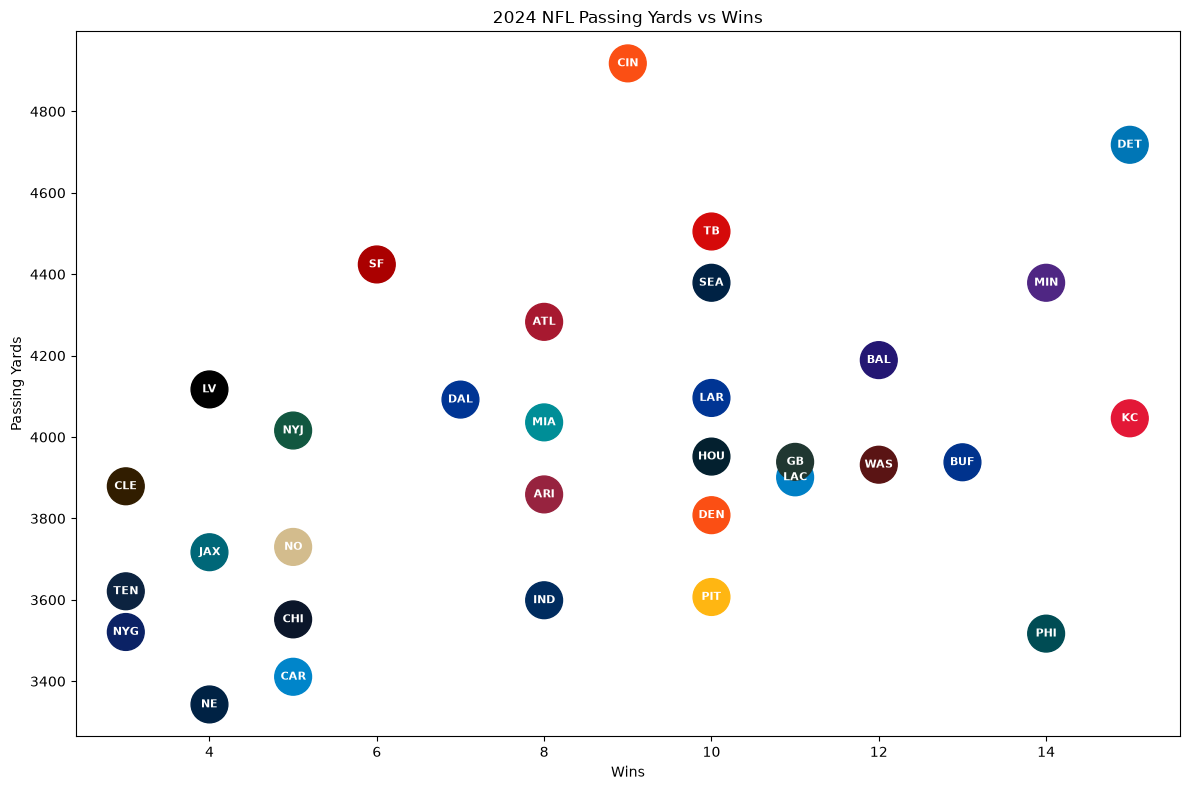

In [48]:
import matplotlib.pyplot as plt

graph_df = standings_clean.merge(offense_df, on="Team_ID")

team_abbr = {
    "Arizona Cardinals": "ARI",
    "Atlanta Falcons": "ATL",
    "Baltimore Ravens": "BAL",
    "Buffalo Bills": "BUF",
    "Carolina Panthers": "CAR",
    "Chicago Bears": "CHI",
    "Cincinnati Bengals": "CIN",
    "Cleveland Browns": "CLE",
    "Dallas Cowboys": "DAL",
    "Denver Broncos": "DEN",
    "Detroit Lions": "DET",
    "Green Bay Packers": "GB",
    "Houston Texans": "HOU",
    "Indianapolis Colts": "IND",
    "Jacksonville Jaguars": "JAX",
    "Kansas City Chiefs": "KC",
    "Las Vegas Raiders": "LV",
    "Los Angeles Chargers": "LAC",
    "Los Angeles Rams": "LAR",
    "Miami Dolphins": "MIA",
    "Minnesota Vikings": "MIN",
    "New England Patriots": "NE",
    "New Orleans Saints": "NO",
    "New York Giants": "NYG",
    "New York Jets": "NYJ",
    "Philadelphia Eagles": "PHI",
    "Pittsburgh Steelers": "PIT",
    "San Francisco 49ers": "SF",
    "Seattle Seahawks": "SEA",
    "Tampa Bay Buccaneers": "TB",
    "Tennessee Titans": "TEN",
    "Washington Commanders": "WAS"
}

colors = [team_colors[team] for team in graph_df["Team_x"]]

plt.figure(figsize=(12, 8))

plt.scatter(
    graph_df["Wins"],
    graph_df["Passing_Yards"],
    s=700,
    c=colors
)

for i in range(len(graph_df)):
    plt.text(
        graph_df["Wins"].iloc[i],
        graph_df["Passing_Yards"].iloc[i],
        team_abbr[graph_df["Team_x"].iloc[i]],
        ha="center",
        va="center",
        color="white",
        fontsize=8,
        fontweight="bold"
    )

plt.xlabel("Wins")
plt.ylabel("Passing Yards")
plt.title("2024 NFL Passing Yards vs Wins")

plt.tight_layout()
plt.show()

This scatter plot shows the relationship between passing yards and wins.  From the graph you can see that there is a moderatley positive relationship between the two. The Bengals are an outlier having the most passing yards but being in the middle for wins. While the Eagles have a low passing yards and a higher number of wins.

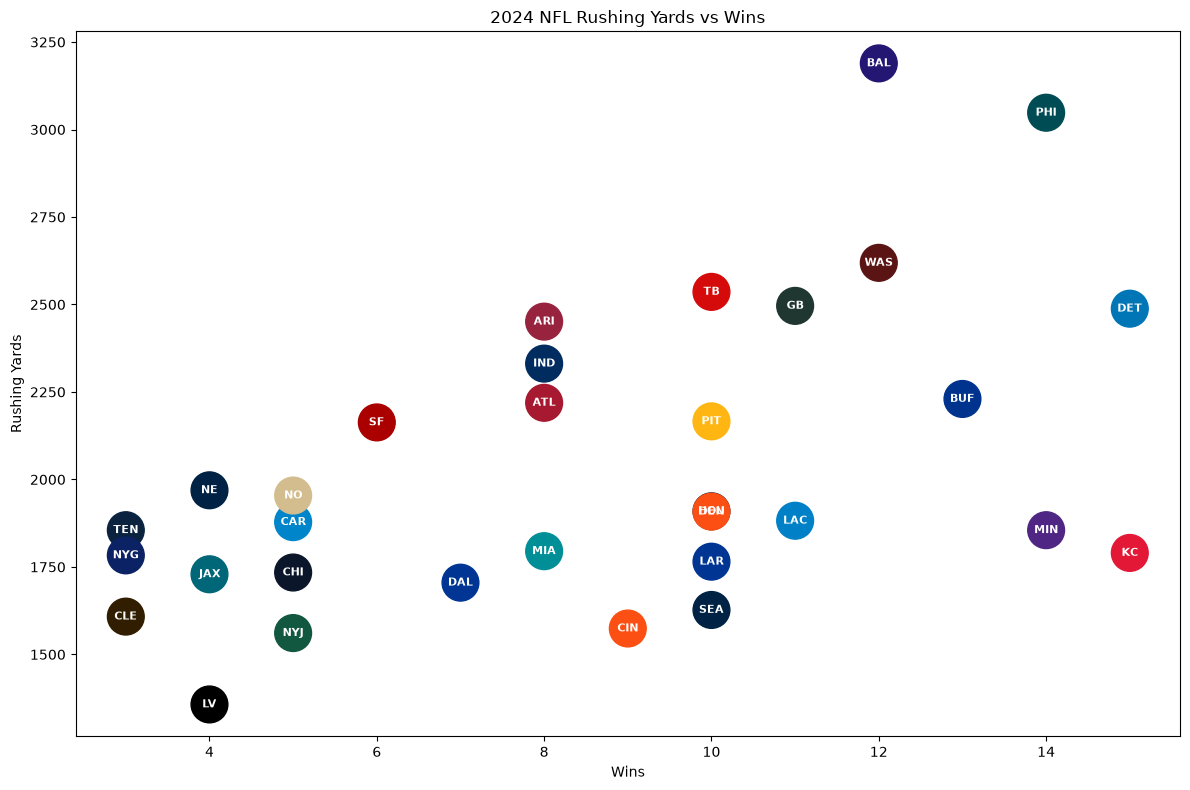

In [49]:
import matplotlib.pyplot as plt

final_df = standings_clean.merge(offense_df, on="Team_ID")

colors = [team_colors[team] for team in graph_df["Team_x"]]

plt.figure(figsize=(12, 8))

plt.scatter(
    final_df["Wins"],
    final_df["Rushing_Yards"],
    s=700,
    c=colors
)

for i in range(len(final_df)):
    plt.text(
        final_df["Wins"].iloc[i],
        final_df["Rushing_Yards"].iloc[i],
        team_abbr[final_df["Team_x"].iloc[i]],
        ha="center",
        va="center",
        color="white",
        fontsize=8,
        fontweight="bold"
    )

plt.xlabel("Wins")
plt.ylabel("Rushing Yards")
plt.title("2024 NFL Rushing Yards vs Wins")

plt.tight_layout()
plt.show()

This scatter plot shows the relationship between rushing yards and wins.  This scatter plot is very positively relationship and shows that the more rushing yard a team has that should result in more wins.  I think this is the case because when a team is up in the second half they are more likely to rush the ball to try and kill the clock quicker. 

In [50]:
passing_corr = graph_df["Wins"].corr(graph_df["Passing_Yards"])
rushing_corr = graph_df["Wins"].corr(graph_df["Rushing_Yards"])

print("Passing correlation:", passing_corr)
print("Rushing correlation:", rushing_corr)

Passing correlation: 0.4096861616817529
Rushing correlation: 0.5249369294577173


## Pearson Correlation Test results
The results from the correlation test shows that rushing yards are more associated with wins than passing yards are.  This could be because when teams are up in the 2nd half they are going to want to run the ball more to kill the clock and finish the end the game quicker. 

In [51]:
# Make an OLS model for wins as the dependent variable and passing yards and rushing yards as independent variables
import statsmodels.formula.api as smf

model = smf.ols(
    "Wins ~ Passing_Yards + Rushing_Yards",
    data=final_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Wins   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     11.71
Date:                Sat, 12 Sep 2026   Prob (F-statistic):           0.000188
Time:                        21:58:46   Log-Likelihood:                -77.356
No. Observations:                  32   AIC:                             160.7
Df Residuals:                      29   BIC:                             165.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       -17.0601      5.985     -2.850

In [52]:
import statsmodels.formula.api as smf

passing_model = smf.ols(
    "Wins ~ Passing_Yards",
    data=graph_df
).fit()

rushing_model = smf.ols(
    "Wins ~ Rushing_Yards",
    data=graph_df
).fit()
print("Passing model summary:")
print(passing_model.summary())


Passing model summary:
                            OLS Regression Results                            
Dep. Variable:                   Wins   R-squared:                       0.168
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     6.051
Date:                Sat, 12 Sep 2026   Prob (F-statistic):             0.0199
Time:                        21:58:47   Log-Likelihood:                -83.886
No. Observations:                  32   AIC:                             171.8
Df Residuals:                      30   BIC:                             174.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -7.591

In [53]:
print("Rushing model summary:")
print(rushing_model.summary())

Rushing model summary:
                            OLS Regression Results                            
Dep. Variable:                   Wins   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     11.41
Date:                Sat, 12 Sep 2026   Prob (F-statistic):            0.00204
Time:                        21:58:47   Log-Likelihood:                -81.668
No. Observations:                  32   AIC:                             167.3
Df Residuals:                      30   BIC:                             170.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.757

## OLS model summary
I created separate OLS models to compare passing yards and rushing yards with wins. The rushing model had a higher R-squared value of 0.276 compared with 0.168 for the passing model, showing that rushing yards had a stronger relationship with wins during the 2024 NFL season. Both variables were statistically significant, but rushing yards had the stronger relationship.

## Conclusion

My findings shows that passing yards and rushing yards both have a positive relationship with regular season wins, but rushing yards had a stronger relationship to wins than passing yards do.  The correlation between rushing yards and wins was about 0.52, compared with about 0.41 for passing yards. The rushing OLS model also had a higher R-squared value of 0.276 compared with 0.168 for the passing model. This suggests that rushing production was more closely associated with team success in the 2024 NFL season. However, this does not mean that rushing yards directly cause more wins because other factors such as defense, turnovers, injuries, and strength of schedule also affect a team’s record.

## Bias and Limitations
The limitation of the data set I used is I could only access data from the 2024 season and they don't include every factor that does into a win for example turnovers, defensive statistics, and injuries are not in the data set.  Another limitation is that the data set did not include team totals for the year in rushing yards and passing yards.  To get around that I had to create a function and loop it through every team's roster.  this created a data quality issue as the Raiders and Commanders came out with wrong data that I had to correct manually.  The bias in this dataset is not including moments in a game when a team might run more run plays to kill the clock when they are up and want to end the game quicker. From an ethical standpoint, I used the data only for analysis, reported the limitations of the dataset, and avoided claiming that passing or rushing yards directly cause wins.  In future research I will add more variables and multiple NFL seasons 

## Github link
 website url- https://smax444.github.io/data-structures-portfolio/                                                                                                            
 repository- https://github.com/smax444/data-structures-portfolio/commit/38b97a65d4b05298115267945be98d7c4f7bcaff

### AI Usage
I used Claude.ai version sonnet 5 to make a checklist for me of what I needed to complete,  helped me with coding the graph so that I had the correct colors and abbreviations in the plots,  help get around the 10 requests per minute restriction from the API source by using time.sleep(7) so that the script took longer to run, and checking the final project for anything that I could have missed.  Without Claude I wouldn't have known about the time.sleep function. I read and understood the final code before I turned in the final project.
https://claude.ai/chat/2213bf94-21e3-44a6-b93d-544d3cf29117


## References


McGough, E., Clemons, C., Ferrara, M., Norfolk, T., & Young, G. W. (2010). A game-theoretic approach to personnel decisions in American football. Journal of Quantitative Analysis in Sports, 6(4), 1–15. https://doi.org/10.2202/1559-0410.1255

Pelechrinis, K., & Papalexakis, E. (2016). The anatomy of American football: Evidence from 7 years of NFL game data. PLOS ONE, 11(12), e0168716. https://doi.org/10.1371/journal.pone.0168716

Quenzel, J., & Shea, P. (2016). Predicting the winner of tied National Football League games: Do the details matter? Journal of Sports Economics, 17(7), 661–671. https://doi.org/10.1177/1527002514539688